In [2]:
import sys
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pathlib import Path
import glob

sys.path.insert(0, str(Path('..').resolve().parent))

In [3]:
"""
Load preprocessed and upsampled datasets.
"""

def load_conditions(samples):
    """Extract the 4 condition arrays from a list of sample dicts."""
    return {
        'trend':            np.array([s['trend']            for s in samples]),
        'realized_vol':     np.array([s['realized_vol']     for s in samples]),
        'interest_rate':    np.array([s['interest_rate']    for s in samples]),
        'volatility_index': np.array([s['volatility_index'] for s in samples]),
    }

# Preprocessed: pool all per-ticker files
prep_samples = []
for f in sorted(glob.glob('../../data/preprocessed/*.json')):
    with open(f) as fp:
        prep_samples.extend(json.load(fp))

# Upsampled: single pooled file
with open('../../data/upsampled/upsampled_data.json') as fp:
    up_samples = json.load(fp)

prep = load_conditions(prep_samples)
up   = load_conditions(up_samples)

print(f"Preprocessed : {len(prep_samples):,} samples")
print(f"Upsampled    : {len(up_samples):,} samples")

Preprocessed : 7,079 samples
Upsampled    : 13,608 samples


In [4]:
"""
Plot configs.
"""

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_PREP = 'tab:blue'
C_UP   = 'tab:orange'

CONDITIONS = [
    # (key,               display_name,         x_label,             log_scale)
    ('trend',            'Trend',               'Trend (%)',         False),
    ('realized_vol',     'Realized Volatility', 'Realized Vol (log scale)', True),
    ('interest_rate',    'Interest Rate',       'Interest Rate (%)', False),
    ('volatility_index', 'Volatility Index',    'VIX',               False),
]

print("Plot config defined.")

Plot config defined.


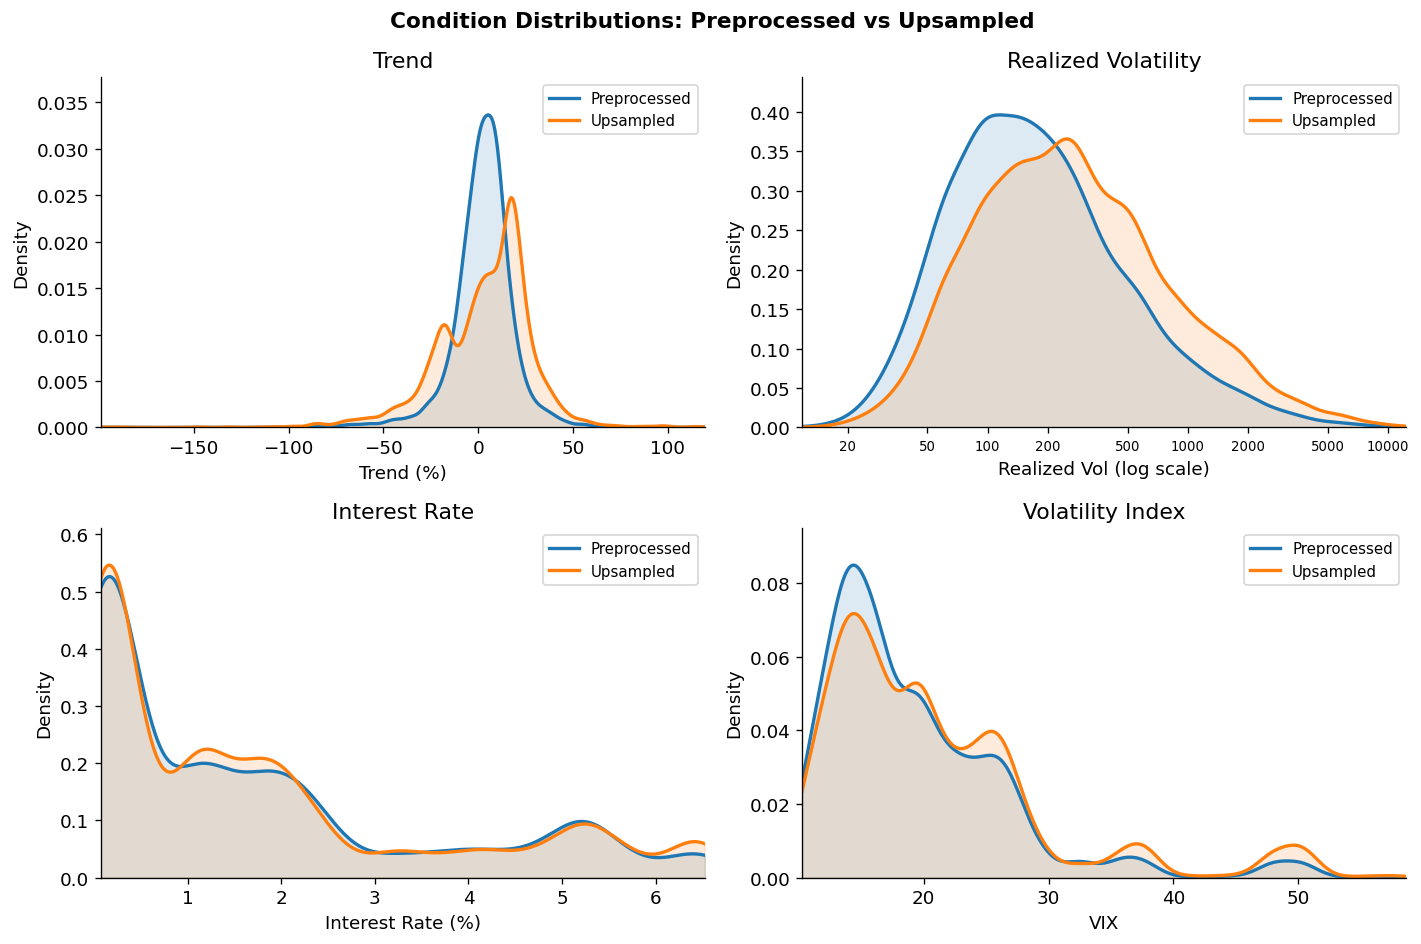

In [7]:
"""
2x2 grid: distribution of each condition, preprocessed vs upsampled.
"""

def plot_kde(ax, values, color, label, log_scale=False):
    """Plot KDE. For log_scale, fit in log space but label ticks with original values."""
    data = np.log(values) if log_scale else values
    kde = gaussian_kde(data, bw_method='scott')
    xs = np.linspace(data.min(), data.max(), 400)
    ax.plot(xs, kde(xs), color=color, lw=2, label=label)
    ax.fill_between(xs, kde(xs), alpha=0.15, color=color)
    return data.min(), data.max(), kde(xs).max()

def set_log_ticks(ax, x_min_log, x_max_log):
    """Place ticks at round original values; label them without log transformation."""
    # Candidate tick values in original space
    candidates = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]
    ticks_log  = [np.log(v) for v in candidates if x_min_log <= np.log(v) <= x_max_log]
    tick_lbls  = [str(v)    for v in candidates if x_min_log <= np.log(v) <= x_max_log]
    ax.set_xticks(ticks_log)
    ax.set_xticklabels(tick_lbls, fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Condition Distributions: Preprocessed vs Upsampled', fontsize=13, fontweight='bold')

for ax, (key, name, xlabel, log_scale) in zip(axes.flat, CONDITIONS):
    x0, x1, y0_prep = plot_kde(ax, prep[key], C_PREP, 'Preprocessed', log_scale)
    x0b, x1b, y0_up = plot_kde(ax, up[key],   C_UP,   'Upsampled',    log_scale)

    # Tight x limits covering both datasets
    ax.set_xlim(min(x0, x0b), max(x1, x1b))
    # y starts at 0, headroom above tallest KDE
    ax.set_ylim(0, max(y0_prep, y0_up) * 1.12)

    if log_scale:
        set_log_ticks(ax, min(x0, x0b), max(x1, x1b))

    ax.set_title(name)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../../figures/cond_distribution.png', bbox_inches='tight')
plt.show()

In [6]:
"""
Summary statistics for each condition.
"""

import pandas as pd

rows = []
for key, name, _, _ in CONDITIONS:
    for label, data in [('Preprocessed', prep[key]), ('Upsampled', up[key])]:
        rows.append({
            'Condition': name,
            'Dataset':   label,
            'N':         len(data),
            'Mean':      data.mean(),
            'Std':       data.std(),
            'Min':       data.min(),
            'Median':    np.median(data),
            'Max':       data.max(),
        })

df = pd.DataFrame(rows).set_index(['Condition', 'Dataset'])
df.style.format({
    'Mean': '{:.3f}', 'Std': '{:.3f}',
    'Min':  '{:.3f}', 'Median': '{:.3f}', 'Max': '{:.3f}',
})